# Real Estate Sales 2001 - 2020 Analysis

###  Import Library 

- pandas untuk manipulasi dan analisis data
- numpy untuk komputasi numerik
- sklearn.preprocessing untuk menyediakan alat untuk prapemrosesan data
- sklearn.model_selection untuk menyediakan alat untuk membagi dataset menjadi set pelatihan dan pengujian
- matplotlib.pyplot untuk uat visualisasi data
- seaborn untuk membuat visualisasi data yang lebih menarik dan informatif
- sklearn.cluster untuk menyediakan algoritma clustering

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans


### Membaca Data




In [ ]:
data = pd.read_csv('/home/fzlfade/Documents/Datasets/Real estate/Real_Estate_Sales_2001-2020_GL.csv')
data.head() 


,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Years until sold
0,2020348,2020,9/13/2021,Ansonia,230 WAKELEE AVE,150500,325000.0,0.4630,Commercial,Nan,1
1,20002,2020,10/2/2020,Ashford,390 TURNPIKE RD,253000,430000.0,0.5883,Residential,Single Family,0
2,200212,2020,3/9/2021,Avon,5 CHESTNUT DRIVE,130400,179900.0,0.7248,Residential,Condo,1
3,200243,2020,4/13/2021,Avon,111 NORTHINGTON DRIVE,619290,890000.0,0.6958,Residential,Single Family,1
4,200377,2020,7/2/2021,Avon,70 FAR HILLS DRIVE,862330,1447500.0,0.5957,Residential,Single Family,1


### Normalisasi

In [6]:
scaler = StandardScaler()
data[['Assessed Value', 'Sale Amount']] = scaler.fit_transform(data[['Assessed Value', 'Sale Amount']])
data.head()


,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Years until sold
0,2020348,2020,9/13/2021,Ansonia,230 WAKELEE AVE,-0.659467,-0.409370,0.4630,Commercial,Nan,1
1,20002,2020,10/2/2020,Ashford,390 TURNPIKE RD,-0.235895,-0.127490,0.5883,Residential,Single Family,0
2,200212,2020,3/9/2021,Avon,5 CHESTNUT DRIVE,-0.742528,-0.798900,0.7248,Residential,Condo,1
3,200243,2020,4/13/2021,Avon,111 NORTHINGTON DRIVE,1.277766,1.107411,0.6958,Residential,Single Family,1
4,200377,2020,7/2/2021,Avon,70 FAR HILLS DRIVE,2.282108,2.604057,0.5957,Residential,Single Family,1


### Pembersihan Data

In [7]:
data = data.dropna()
print(f"Jumlah data setelah pembersihan: {data.shape[0]}")


Jumlah data setelah pembersihan: 20


### Split Data untuk Pelatihan dan Pengujian

In [8]:
X = data[['Assessed Value', 'Sale Amount']]
y = data['Sales Ratio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data latih: {X_train.shape}, Data uji: {X_test.shape}")


Data latih: (16, 2), Data uji: (4, 2)


### Visualisasi Scatter Plot

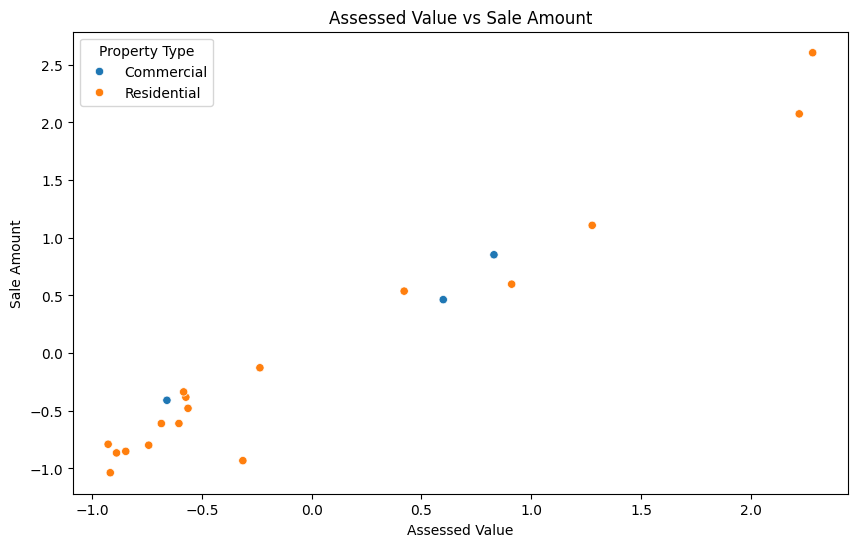

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Assessed Value', y='Sale Amount', hue='Property Type')
plt.title('Assessed Value vs Sale Amount')
plt.show()


### K-Means Clustering

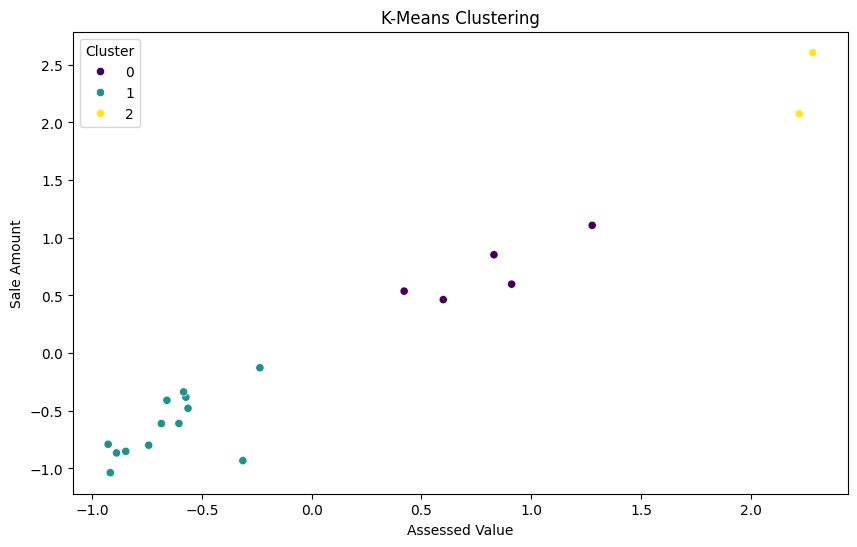

In [10]:
kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Assessed Value', y='Sale Amount', hue='Cluster', palette='viridis')
plt.title('K-Means Clustering')
plt.show()


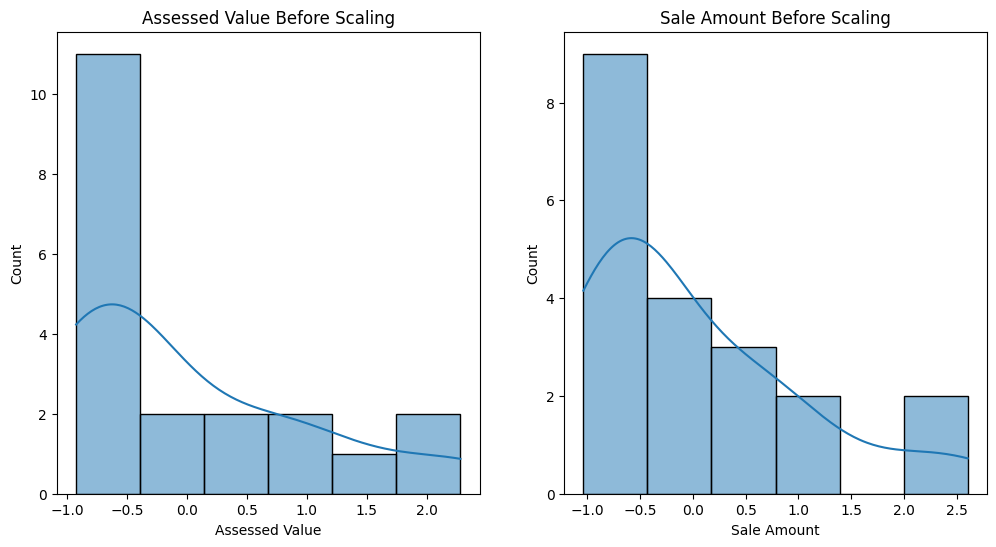

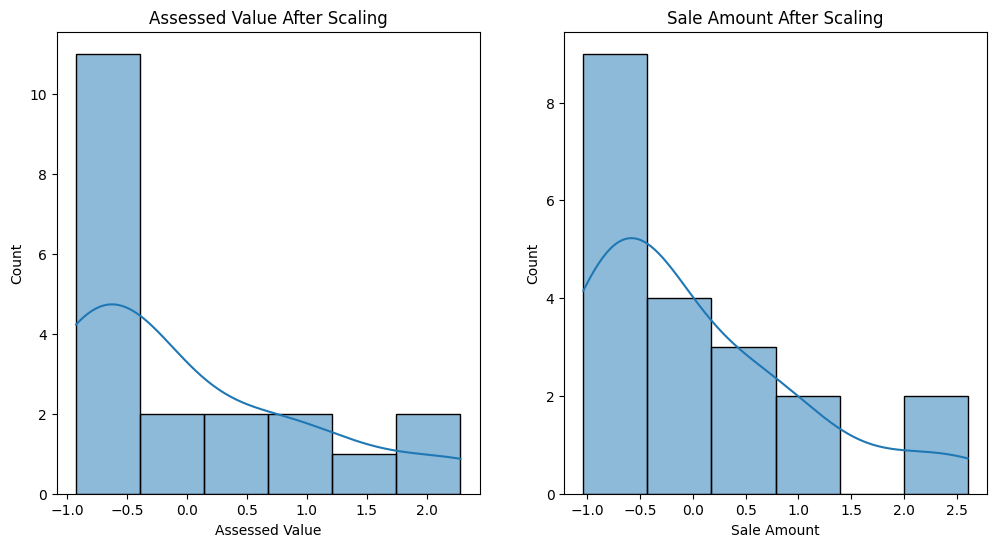

In [11]:
# Sebelum Normalisasi
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(data['Assessed Value'], kde=True)
plt.title('Assessed Value Before Scaling')
plt.subplot(1, 2, 2)
sns.histplot(data['Sale Amount'], kde=True)
plt.title('Sale Amount Before Scaling')
plt.show()

# Setelah Normalisasi
scaler = StandardScaler()
data[['Assessed Value', 'Sale Amount']] = scaler.fit_transform(data[['Assessed Value', 'Sale Amount']])
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(data['Assessed Value'], kde=True)
plt.title('Assessed Value After Scaling')
plt.subplot(1, 2, 2)
sns.histplot(data['Sale Amount'], kde=True)
plt.title('Sale Amount After Scaling')
plt.show()